In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
folder = Path.cwd()
info_file = next(folder.glob("calibration-*.csv"), None)

In [3]:
df = pd.read_csv(info_file)
df

,L/R,p_x,p_y,p_z,a_x,a_y,a_z,v_x,v_y,v_z,t
0,L,-0.212673,0.626128,-0.106313,-0.005840,0.002439,0.003478,-0.385448,-0.752948,0.473227,0.032549
1,L,-0.212526,0.626133,-0.106349,0.011373,0.000333,-0.002866,1.336154,-0.163482,-0.492412,0.045431
2,L,-0.212431,0.626130,-0.106373,0.006935,-0.000240,-0.001745,-0.324808,-0.041938,0.082035,0.059095
3,L,-0.212421,0.626236,-0.106521,0.000622,0.006330,-0.008818,-0.376152,0.391487,-0.421484,0.075876
4,L,-0.212410,0.626346,-0.106679,0.001010,0.010385,-0.014810,0.036455,0.381307,-0.563390,0.086512
...,...,...,...,...,...,...,...,...,...,...,...
1429,R,0.184872,1.417417,-0.020668,-0.915647,-0.566022,-0.690262,-21.381210,-42.228550,-47.092940,9.921232
1430,R,0.173406,1.412204,-0.028212,-0.871220,-0.396141,-0.573201,3.375747,12.908190,8.894751,9.934393
1431,R,0.168705,1.401163,-0.039326,-0.337521,-0.792528,-0.797825,38.309410,-28.453020,-16.123730,9.948324
1432,R,0.162924,1.393381,-0.048150,-0.419027,-0.564151,-0.639656,-5.908888,16.556350,11.466540,9.962118


In [4]:
acc_df = df[[col for col in df.columns if col.startswith('a_') or col == 't']]
acc_df

,a_x,a_y,a_z,t
0,-0.005840,0.002439,0.003478,0.032549
1,0.011373,0.000333,-0.002866,0.045431
2,0.006935,-0.000240,-0.001745,0.059095
3,0.000622,0.006330,-0.008818,0.075876
4,0.001010,0.010385,-0.014810,0.086512
...,...,...,...,...
1429,-0.915647,-0.566022,-0.690262,9.921232
1430,-0.871220,-0.396141,-0.573201,9.934393
1431,-0.337521,-0.792528,-0.797825,9.948324
1432,-0.419027,-0.564151,-0.639656,9.962118


In [5]:
L_df = acc_df[df['L/R'] == 'L']
R_df = acc_df[df['L/R'] == 'R']

In [6]:
def plot_3d(L_df, R_df, eval):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw={'projection': '3d'})
    # left hand
    sm1 = axes[0].scatter(L_df['a_x'], L_df['a_z'], L_df['a_y'], c = L_df['t'], cmap='viridis')
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('y')
    axes[0].set_zlabel('z')
    axes[0].set_title(f'Left Hand {eval} (3D)')
    plt.colorbar(sm1, label = 'timestamp', orientation = 'horizontal')

    # reft hand
    sm2 = axes[1].scatter(R_df['a_x'], R_df['a_z'], R_df['a_y'], c = R_df['t'], cmap='viridis')
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('y')
    axes[1].set_zlabel('z')
    axes[1].set_title(f'Right Hand {eval} (3D)')


    plt.colorbar(sm2, label = 'timestamp', orientation = 'horizontal')
    plt.show()

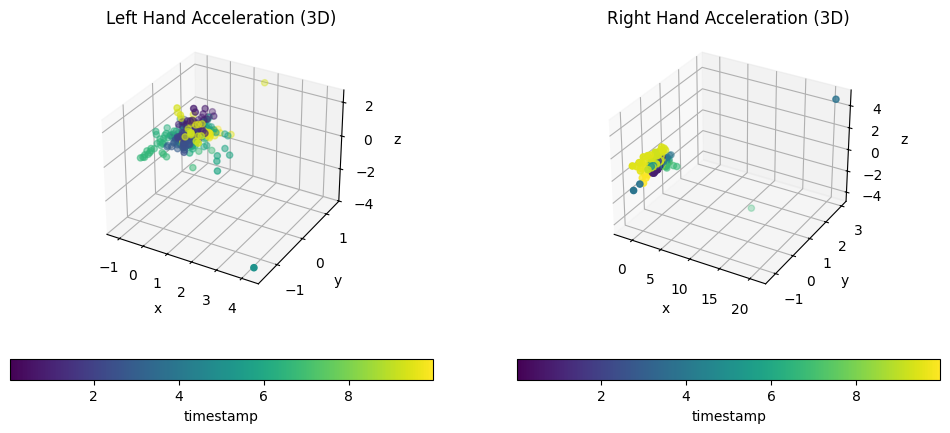

In [7]:
plot_3d(L_df, R_df, eval = 'Acceleration')

In [8]:
# fig = plt.figure()
# ax = plt.axes(projection = '3d')
# sm = ax.scatter(L_df['a_x'], L_df['a_z'], L_df['a_y'], c = L_df['t'], alpha = 1, cmap = 'viridis')
# ax.set_xlabel('x')
# ax.set_ylabel('y')
# ax.set_zlabel('z')

# plt.colorbar(sm, label = 'timestamp', orientation = 'horizontal')
# plt.title(f'Left Hand Acceleration (3D)')
# plt.show()

In [9]:
def plot_Z_Timestamp(ax, df, title, pos_threshold=0.2, neg_threshold=-0.2):
    pos_peaks = df[(df['a_z'] > pos_threshold )& (df['a_z'] > df['a_z'].shift(1)) & (df['a_z'] > df['a_z'].shift(-1))]
    neg_peaks = df[(df['a_z'] < neg_threshold )& (df['a_z'] < df['a_z'].shift(1)) & (df['a_z'] < df['a_z'].shift(-1))]

    ax.plot(df['t'], df['a_z'], alpha = 0.5)
    ax.axhline(y = 0, linestyle = '--', color = 'red')

    ax.scatter(pos_peaks['t'], pos_peaks['a_z'],s = 10, alpha = 0.6, color = 'green', facecolors = 'none', label = 'Positive Peaks')
    top_5pos_peaks = pos_peaks.nlargest(5, 'a_z') 
    for _, row in top_5pos_peaks.iterrows():
        ax.text(row['t'], row['a_z'], f"{row['t']:.2f}", fontsize=8)

    ax.scatter(neg_peaks['t'], neg_peaks['a_z'],s = 10, alpha = 0.6, color = 'orange', facecolors = 'none', label = 'Negative Peaks')
    top_5neg_peaks = neg_peaks.nsmallest(5, 'a_z') 
    for _, row in top_5neg_peaks.iterrows():
        ax.text(row['t'], row['a_z'], f"{row['t']:.2f}", fontsize=8)
    
    
    ax.set_xlabel('Timestamp (seconds)')
    ax.set_ylabel('z')
    ax.legend()
    ax.set_title(title)

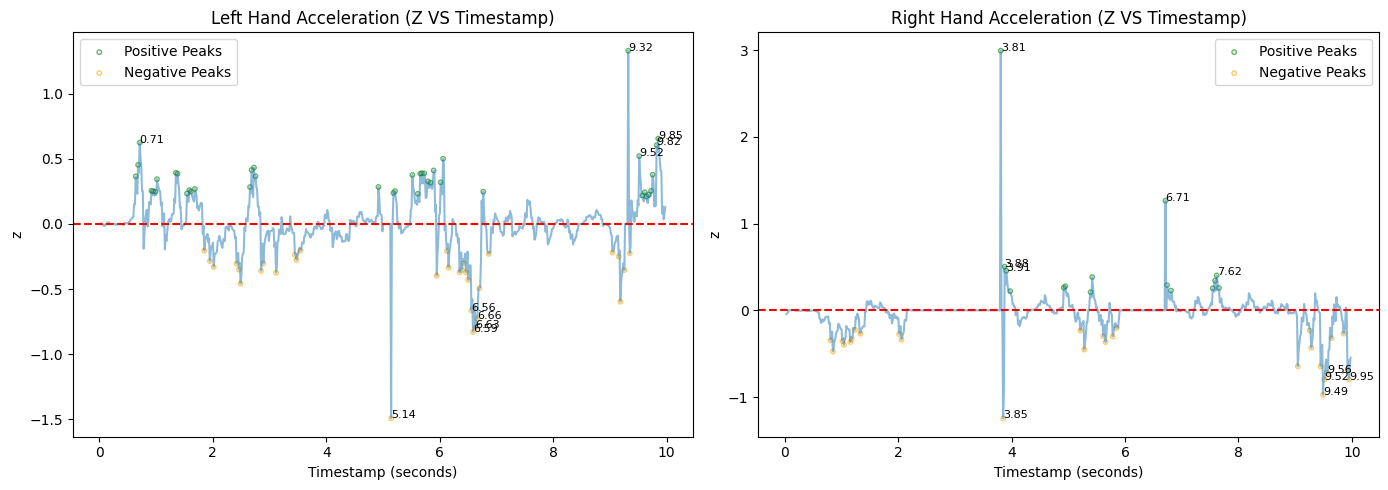

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_Z_Timestamp(axes[0], L_df, 'Left Hand Acceleration (Z VS Timestamp)')
plot_Z_Timestamp(axes[1], R_df, 'Right Hand Acceleration (Z VS Timestamp)')
plt.tight_layout()
plt.show()

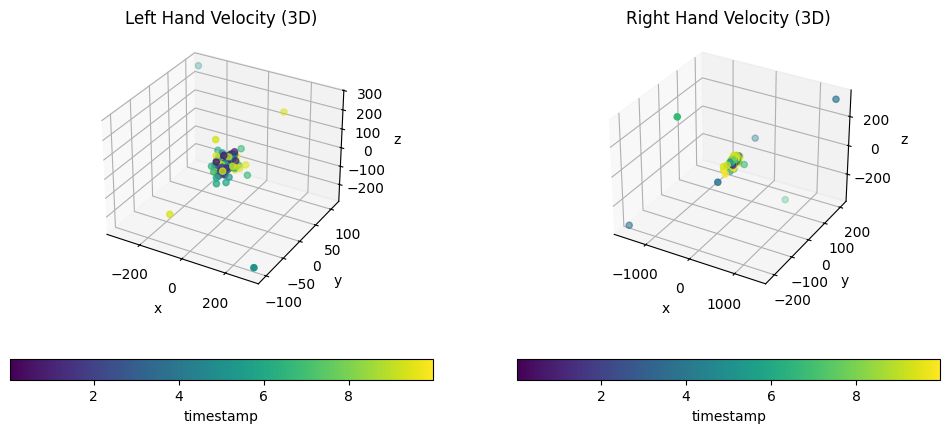

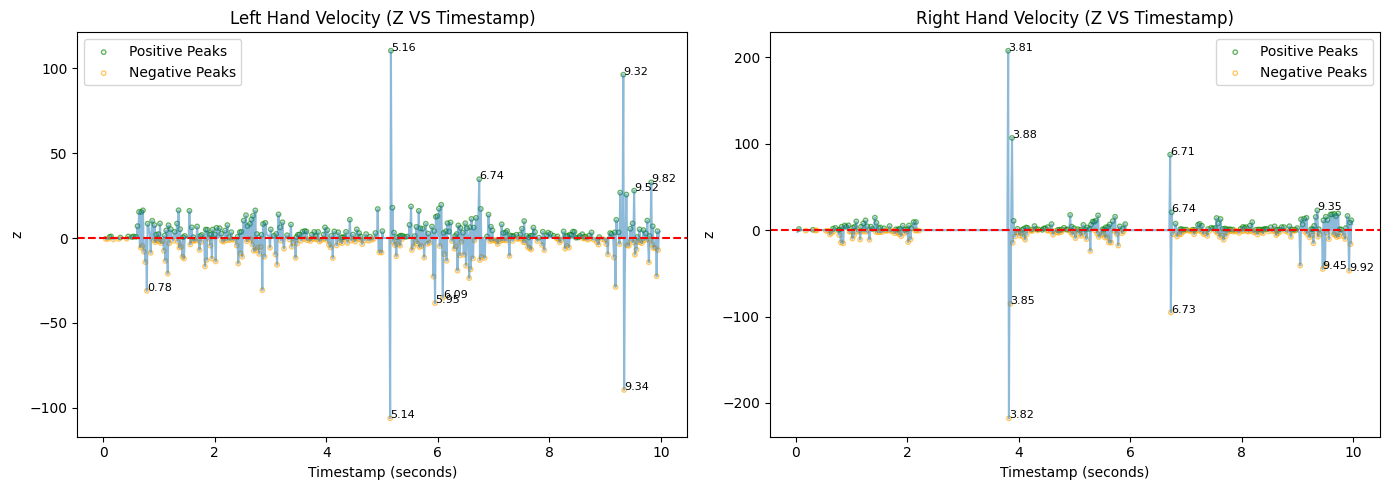

In [11]:
vel_df = df[[col for col in df.columns if col.startswith('v_') or col == 't']]
vel_df = vel_df.rename(columns={
    'v_x' : 'a_x',
    'v_y' : 'a_y',
    'v_z' : 'a_z',

})
L_vel_df = vel_df[df['L/R'] == 'L']
R_vel_df = vel_df[df['L/R'] == 'R']
plot_3d(L_vel_df, R_vel_df, eval = 'Velocity')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_Z_Timestamp(axes[0], L_vel_df, 'Left Hand Velocity (Z VS Timestamp)')
plot_Z_Timestamp(axes[1], R_vel_df, 'Right Hand Velocity (Z VS Timestamp)')
plt.tight_layout()
plt.show()


In [12]:
# pos_threshold = 0.2
# neg_threshold = -0.2
# pos_peaks = L_df[(L_df['a_z'] > pos_threshold )& (L_df['a_z'] > L_df['a_z'].shift(1)) & (L_df['a_z'] > L_df['a_z'].shift(-1))]
# neg_peaks = L_df[(L_df['a_z'] < neg_threshold )& (L_df['a_z'] < L_df['a_z'].shift(1)) & (L_df['a_z'] < L_df['a_z'].shift(-1))]


# plt.plot(L_df['t'], L_df['a_z'], alpha = 0.3)
# plt.axhline(y = 0, linestyle = '--', color = 'red')

# plt.scatter(pos_peaks['t'], pos_peaks['a_z'],s = 10, alpha = 0.5, color = 'green', facecolors = 'none', label = 'Positive Peaks')
# top_5pos_peaks = pos_peaks.nlargest(5, 'a_z') 
# for _, row in top_5pos_peaks.iterrows():
#     plt.text(row['t'], row['a_z'], f"{row['t']:.2f}", fontsize=8)



# plt.scatter(neg_peaks['t'], neg_peaks['a_z'],s = 10, alpha = 0.5, color = 'orange', facecolors = 'none', label = 'Negative Peaks')
# top_5neg_peaks = neg_peaks.nsmallest(5, 'a_z') 
# for _, row in top_5neg_peaks.iterrows():
#     plt.text(row['t'], row['a_z'], f"{row['t']:.2f}", fontsize=8)
# plt.xlabel('Timestamp (seconds)')
# plt.ylabel('z')
# plt.legend()
# plt.title(f'Left Hand Acceleration (Z VS Timestamp)')
# plt.show()